# Assignment 2
##### EECE 5644- Introduction to Machine Learning

This notebook processes the Telco data and performs linear regression to make predictions.

1. Load and inspect the data read telco.csv (7,043 rows), confirm the target is target (MonthlyCharges,
continuous), and verify the service columns are clean 0/1 indicators with no missing values.

In [ ]:
import pandas as pd
import sklearn as sk

# Read the raw dataframe
df = pd.read_csv('telco.csv')

# Verify the datatype of the target
print("Target type: ", df["target"].dtype)
print("Maximum target value: ", df["target"].max())
print("Maximum target value: ", df["target"].min())

# Store a list of service columns
services = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", 
"StreamingTV", "StreamingMovies", "InternetService_Fiber optic", "InternetService_No"]

all_services_valid = True

# Go through each column and check if it is clean
for service in services:

    # Check if the column is only 0's and 1's without any NaN's
    if not df[service].isin([0, 1]).all():
        all_services_valid = False
        break

# Drop unused columns
df = df[["target"] + services]

print("\nAll service columns clean 0/1 indicators with no missing values:", all_services_valid)
df.to_csv("clean_online_retail.csv", index=False)

Target type:  float64
Maximum target value:  118.75
Maximum target value:  18.25

All service columns clean 0/1 indicators with no missing values: True
3.0.3
1.9.0


2. Define the variables set the target as MonthlyCharges and the predictors as the ten service indicators
(PhoneService, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport,
StreamingTV, StreamingMovies, InternetService_Fiber optic, InternetService_No).

In [10]:
X = df[services]
y = df['target']
X.head(3)

,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,InternetService_Fiber optic,InternetService_No
0,0,0,0,1,0,0,0,0,0,0
1,1,0,1,0,1,0,0,0,0,0
2,1,0,1,1,0,0,0,0,0,0


3. Split the data hold out a test set (80/20) with a fixed random seed so results are reproducible

In [11]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

4. Fit a multivariable linear regression train the model 𝑦̂ = 𝑤0 + ∑ 𝑤𝑖𝑖 𝑥𝑖on the training set

In [12]:
model = sk.linear_model.LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 20.04, 5.01, 5.05,..., 9.95, 24.95,-25.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['PhoneService','MultipleLines','OnlineSecurity',...,'StreamingMovies', 'InternetService_Fiber optic','InternetService_No']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,24.97
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


5. Report the parameters output the intercept (base-plan charge) and all ten coefficients (dollar
contribution of each service).

In [13]:
coefficients = model.coef_
intercept = model.intercept_

print(f"Intercept (base-plan charge): ${intercept.round(2)}")
for i in range(len(services)):
    print(f"Coefficient for {services[i]}: ${coefficients[i].round(2)}")

Intercept (base-plan charge): $24.97
Coefficient for PhoneService: $20.04
Coefficient for MultipleLines: $5.01
Coefficient for OnlineSecurity: $5.05
Coefficient for OnlineBackup: $4.98
Coefficient for DeviceProtection: $5.01
Coefficient for TechSupport: $5.03
Coefficient for StreamingTV: $9.98
Coefficient for StreamingMovies: $9.95
Coefficient for InternetService_Fiber optic: $24.95
Coefficient for InternetService_No: $-25.05


6. Evaluate on the test set report at least R² and mean absolute error (MAE), and ideally RMSE.

In [14]:
# Perform prediction
y_pred = model.predict(X_test)

r2 = sk.metrics.r2_score(y_test, y_pred)
mae = sk.metrics.mean_absolute_error(y_test, y_pred)
rmse = sk.metrics.mean_squared_error(y_test, y_pred) ** 0.5
print(f"R2  : {round(r2, 3)}")
print(f"MAE : ${round(mae, 2)}")
print(f"RMSE: ${round(rmse, 2)}")

R2  : 0.999
MAE : $0.79
RMSE: $1.05


7. Compare to a baseline show the multivariable model beats the original single-variable model (count
of add-ons) on the same split.

In [15]:
# Generate a list of the number of services 
service_count = df[services].sum(axis=1).to_frame()

# Split the data
sv_x_train, sv_x_test, sv_y_train, sv_y_test = sk.model_selection.train_test_split(service_count, y, test_size=0.2, random_state=42)

# Perform the Linear Regression
sv_model = sk.linear_model.LinearRegression()
sv_model.fit(sv_x_train, sv_y_train)

# Perform the single variable prediction
sv_y_pred = sv_model.predict(sv_x_test)

# Generate the metrics
sv_r2 = sk.metrics.r2_score(sv_y_test, sv_y_pred)
sv_mae = sk.metrics.mean_absolute_error(sv_y_test, sv_y_pred)
sv_rmse = sk.metrics.mean_squared_error(sv_y_test, sv_y_pred) ** 0.5

# Display the results
print(f"Single Variable R2  : {round(sv_r2, 3)} (vs {round(r2, 3)} mv)")
print(f"MAE : ${round(sv_mae, 2)} (vs ${round(mae, 2)} mv)")
print(f"RMSE: ${round(sv_rmse, 2)} (vs ${round(rmse, 3)} mv)")


Single Variable R2  : 0.701 (vs 0.999 mv)
MAE : $14.24 (vs $0.79 mv)
RMSE: $16.46 (vs $1.05 mv)


8. Interpret the results translate coefficients into plain business terms (each weight ≈ the monthly price
of that service).

In [16]:
print(f"For Telco mobile plans, the price for a basic plan is ${intercept.round(2)}.")
for i in range(len(services)):
    print(f"For the {services[i]} add-on, the price is ${coefficients[i].round(2)}.")

For Telco mobile plans, the price for a basic plan is $24.97.
For the PhoneService add-on, the price is $20.04.
For the MultipleLines add-on, the price is $5.01.
For the OnlineSecurity add-on, the price is $5.05.
For the OnlineBackup add-on, the price is $4.98.
For the DeviceProtection add-on, the price is $5.01.
For the TechSupport add-on, the price is $5.03.
For the StreamingTV add-on, the price is $9.98.
For the StreamingMovies add-on, the price is $9.95.
For the InternetService_Fiber optic add-on, the price is $24.95.
For the InternetService_No add-on, the price is $-25.05.


9. Make a prediction given a new customer's chosen bundle, output an expected monthly charge.

In [17]:
# Generate the bundle for a new user
new_bundle = pd.Series({
    "PhoneService": 1, "MultipleLines": 1, "OnlineSecurity": 0, "OnlineBackup": 0, "DeviceProtection": 0, "TechSupport": 1, 
    "StreamingTV": 0, "StreamingMovies": 0, "InternetService_Fiber optic": 0, "InternetService_No": 0
}).to_frame().T

# Make the prediction on this new bundle
prediction = model.predict(new_bundle)[0]

# Display the prediction
print(f"The predicted price for a bundle with phone service, multiple lines, and tech support is ${round(prediction, 2)}.")

The predicted price for a bundle with phone service, multiple lines, and tech support is $55.05.


Deliverable- Generate Data Dictionary

In [20]:
# Generate the data dictionary
data_dictionary = pd.DataFrame([
    ["target",                      "float",    "The monthly charge of the phone plan",                 "USD"],
    ["PhoneService",                "binary",   "Whether or not the customer has phone service",        "0/1"],
    ["MultipleLines",               "binary",   "Whether or not the customer has multiple lines",       "0/1"],
    ["OnlineSecurity",              "binary",   "Whether or not the customer has online security",      "0/1"],
    ["OnlineBackup",                "binary",   "Whether or not the customer has an online backup",     "0/1"],
    ["DeviceProtection",            "binary",   "Whether or not the customer has device protection",    "0/1"],
    ["TechSupport",                 "binary",   "Whether or not the customer gets tech support",        "0/1"],
    ["StreamingTV",                 "binary",   "Whether or not the customer has streaming TV",         "0/1"],
    ["StreamingMovies",             "binary",   "Whether or not the customer can stream movies",        "0/1"],
    ["InternetService_Fiber optic", "binary",   "Whether or not the customer has fiber optic",          "0/1"],
    ["InternetService_No",          "binary",   "If the use does not have internet service",            "0/1"]
], columns=["Column", "Datatype", "Description", "Units"])

data_dictionary.to_csv("data_dictionary.csv", index=False)


Generate Plots for Findings

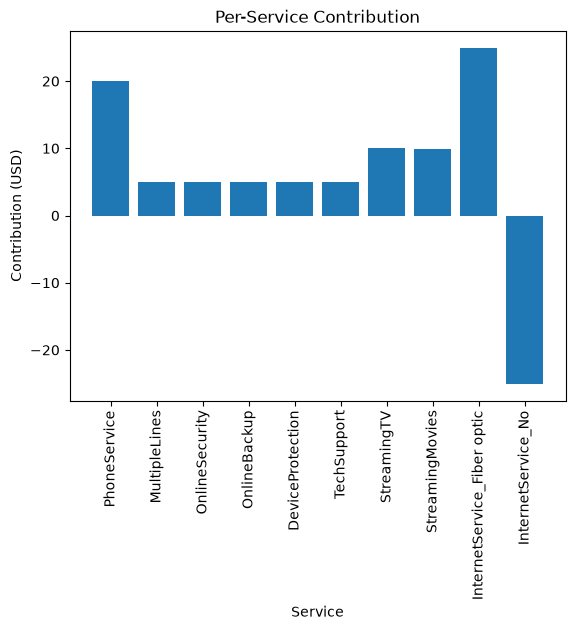

TypeError: scatter() missing 1 required positional argument: 'y'

In [ ]:
import matplotlib.pyplot as plt

plt.bar(services, coefficients)
plt.xlabel("Service")
plt.xticks(rotation=90)
plt.ylabel("Contribution (USD)")
plt.title("Per-Service Contribution")
plt.show()

plt.scatter(y_train, sv_y_pred)

